# Global Distribution of WS/DGAT Biosynthetic Potential in Marine Sediment Metagenomes

**Author:** Virginia Galván, PhD  
**Associated publication / thesis reference:** doctoral thesis, Chapter I — Section 7.3.7, Figure 13

---

## Biological context

Notebook 01 characterized WS/DGAT biosynthetic potential (Pfam domain **PF03007**) in 13 Subantarctic and Antarctic subtidal metagenomes from a single, chronically hydrocarbon-polluted site. A natural question follows: is this biosynthetic potential a local peculiarity of that site, or a consistent feature of marine sediment microbial communities worldwide?

This notebook surveys **101 additional marine sediment metagenomes** from the IMG/M database (https://img.jgi.doe.gov/), spanning highly diverse geographic locations, and asks whether the relative abundance of WS/DGAT homologs observed previously generalizes at a global scale — independent of any single site's local conditions.

## 0. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px

# Path configuration: works whether the notebook is run from the repo's
# notebooks/ folder (data/ one level up) or from the same directory as the data files
DATA_DIR = '../data' if os.path.exists('../data') else '.'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150
})

# Relative-abundance tiers, consistent across the WS/DGAT notebook series
ABUNDANCE_COLORS = {
    'low': '#c6dbef',       # mean_ratio <= 1
    'medium': '#4292c6',    # 1 < mean_ratio <= 2
    'high': '#08306b'       # mean_ratio > 2
}

print(f'Data directory: {DATA_DIR}')

Data directory: .


## 1. Load and process data

**Pfam domains used (13 total):**
- Target: **PF03007** (WS/DGAT — putative neutral lipid biosynthesis gene)
- Reference: 12 single-copy ribosomal protein domains (PF00189, PF00252, PF00453, PF00542, PF00831, PF00886, PF01016, PF01196, PF01245, PF01250, PF01281, PF01649), used to normalize for differences in metagenome size and sequencing depth (same approach as Notebook 01).

**Data source:** Pfam domain hit counts were retrieved from IMG/M for 113 marine sediment metagenomes (filtered by ecosystem type = marine sediment). Geographic coordinates and GOLD Study ID were exported from the same database.

In [2]:
# Data availability:
# All 113 marine sediment metagenomes are publicly available at IMG/M (https://img.jgi.doe.gov/),
# filtered by Ecosystem Category = Aquatic, Ecosystem Type = Sediment, Specific Ecosystem = Marine.
# IMG Genome IDs and GOLD Study IDs for each metagenome are listed in the metadata table below.

# --- Gene counts: PF03007 + 12 ribosomal marker domains, per metagenome ---
gene_counts = pd.read_csv(f'{DATA_DIR}/marine_metagenomes_gene_counts_repo1.csv')
gene_counts['metagenome_id'] = gene_counts['metagenome_id'].astype(str)
gene_counts = gene_counts.set_index('metagenome_id')

# --- Metadata: coordinates and sequencing project (GOLD Study) ---
metadata = pd.read_csv(f'{DATA_DIR}/marine_metagenomes_metadata_repo1.csv')
metadata['metagenome_id'] = metadata['metagenome_id'].astype(str)

print(f'Gene counts table: {gene_counts.shape[0]} metagenomes x {gene_counts.shape[1]} Pfam domains')
print(f'Metadata table: {metadata.shape[0]} metagenomes')
gene_counts.head(3)

Gene counts table: 113 metagenomes x 13 Pfam domains
Metadata table: 113 metagenomes


,pfam03007,pfam00189,pfam00252,pfam00453,pfam00542,pfam00831,pfam00886,pfam01016,pfam01196,pfam01245,pfam01250,pfam01281,pfam01649
metagenome_id,,,,,,,,,,,,,
3300000118,23,27,36,23,19,32,20,17,27,23,27,19,20
3300000119,103,134,179,159,138,145,148,162,140,166,137,119,155
3300000121,116,26,37,42,27,36,17,32,35,34,40,26,27


### 1.1 Compute relative abundance

Relative abundance of PF03007 in each metagenome is the **mean of 12 ratios** (PF03007 count / each ribosomal marker count) — identical methodology to Notebook 01. Because both terms of each ratio come from the same metagenome, this metric is invariant to sequencing depth by construction: any per-metagenome depth-correction factor would apply identically to numerator and denominator and cancel out algebraically. Depth correction is therefore not applied here (it would only matter when comparing *raw* Pfam counts across metagenomes of different sizes, which this analysis never does).

`n_valid` tracks how many of the 12 ratios were computable (a ribosomal marker with zero hits in a given metagenome produces an undefined ratio, recorded as `NaN`, and is simply excluded from that metagenome's mean rather than treated as a hard failure).

**QC threshold:** a metagenome is retained only if at least 6 of its 12 ratios are valid (i.e. no more than half of the ribosomal markers failed to be detected). Below this, the mean would be driven by too few markers to be a reliable estimate.

In [3]:
pfam_target = 'pfam03007'
pfams_ref = [c for c in gene_counts.columns if c != pfam_target]

ratios = pd.DataFrame(index=gene_counts.index)
numerator = gene_counts[pfam_target].astype(float)

for ref in pfams_ref:
    with np.errstate(divide='ignore', invalid='ignore'):
        r = numerator / gene_counts[ref].astype(float)
        r = r.replace([np.inf, -np.inf], np.nan)
    ratios[f'ratio_over_{ref}'] = r

ratios['mean_ratio'] = ratios.mean(axis=1, skipna=True)
ratios['std_ratio'] = ratios.std(axis=1, ddof=1, skipna=True)
ratios['n_valid'] = ratios.iloc[:, :len(pfams_ref)].notna().sum(axis=1)

MIN_VALID_RATIOS = 6
n_failed_qc = (ratios['n_valid'] < MIN_VALID_RATIOS).sum()
print(f'Metagenomes failing QC (n_valid < {MIN_VALID_RATIOS}/12): {n_failed_qc}')

ratios = ratios[ratios['n_valid'] >= MIN_VALID_RATIOS]
df = gene_counts.join(ratios[['mean_ratio', 'std_ratio', 'n_valid']]).join(
    metadata.set_index('metagenome_id')
)
print(f'Metagenomes passing QC: {df.shape[0]} / {gene_counts.shape[0]}')

Metagenomes failing QC (n_valid < 6/12): 0
Metagenomes passing QC: 113 / 113


### 1.2 Exclude metagenomes already analyzed in Notebook 01

The initial IMG/M query (filtered by marine sediment ecosystem) also retrieved the 12 Bahía Ushuaia (ARG01–06) and Caleta Potter (ANT01–06) metagenomes already characterized in Notebook 01. These are removed here to avoid double-counting, leaving the independent global comparison set.

In [4]:
LOCAL_METAGENOME_IDS = [
    '3300000125', '3300000131', '3300000121', '3300000122', '3300000242', '3300000118',  # ARG01-06
    '3300000119', '3300000136', '3300000135', '3300000129', '3300000132', '3300000123'   # ANT01-06
]

n_before = len(df)
df = df.drop(index=[i for i in LOCAL_METAGENOME_IDS if i in df.index])
df = df.sort_values('mean_ratio', ascending=False).reset_index()
df['rank'] = np.arange(1, len(df) + 1)

def abundance_tier(v):
    if v <= 1:
        return 'low'
    elif v <= 2:
        return 'medium'
    return 'high'

df['abundance_tier'] = df['mean_ratio'].apply(abundance_tier)

print(f'Metagenomes: {n_before} -> {len(df)} after removing {n_before - len(df)} already analyzed in Notebook 01')

Metagenomes: 113 -> 101 after removing 12 already analyzed in Notebook 01


## 2. Figure 1 — Relative WS/DGAT abundance ranked across 101 metagenomes

Same visual convention as Notebook 01: mean ± SD of the 12 marker ratios per metagenome, colored by abundance tier, dashed line at y = 1 marking parity with the average single-copy ribosomal gene.

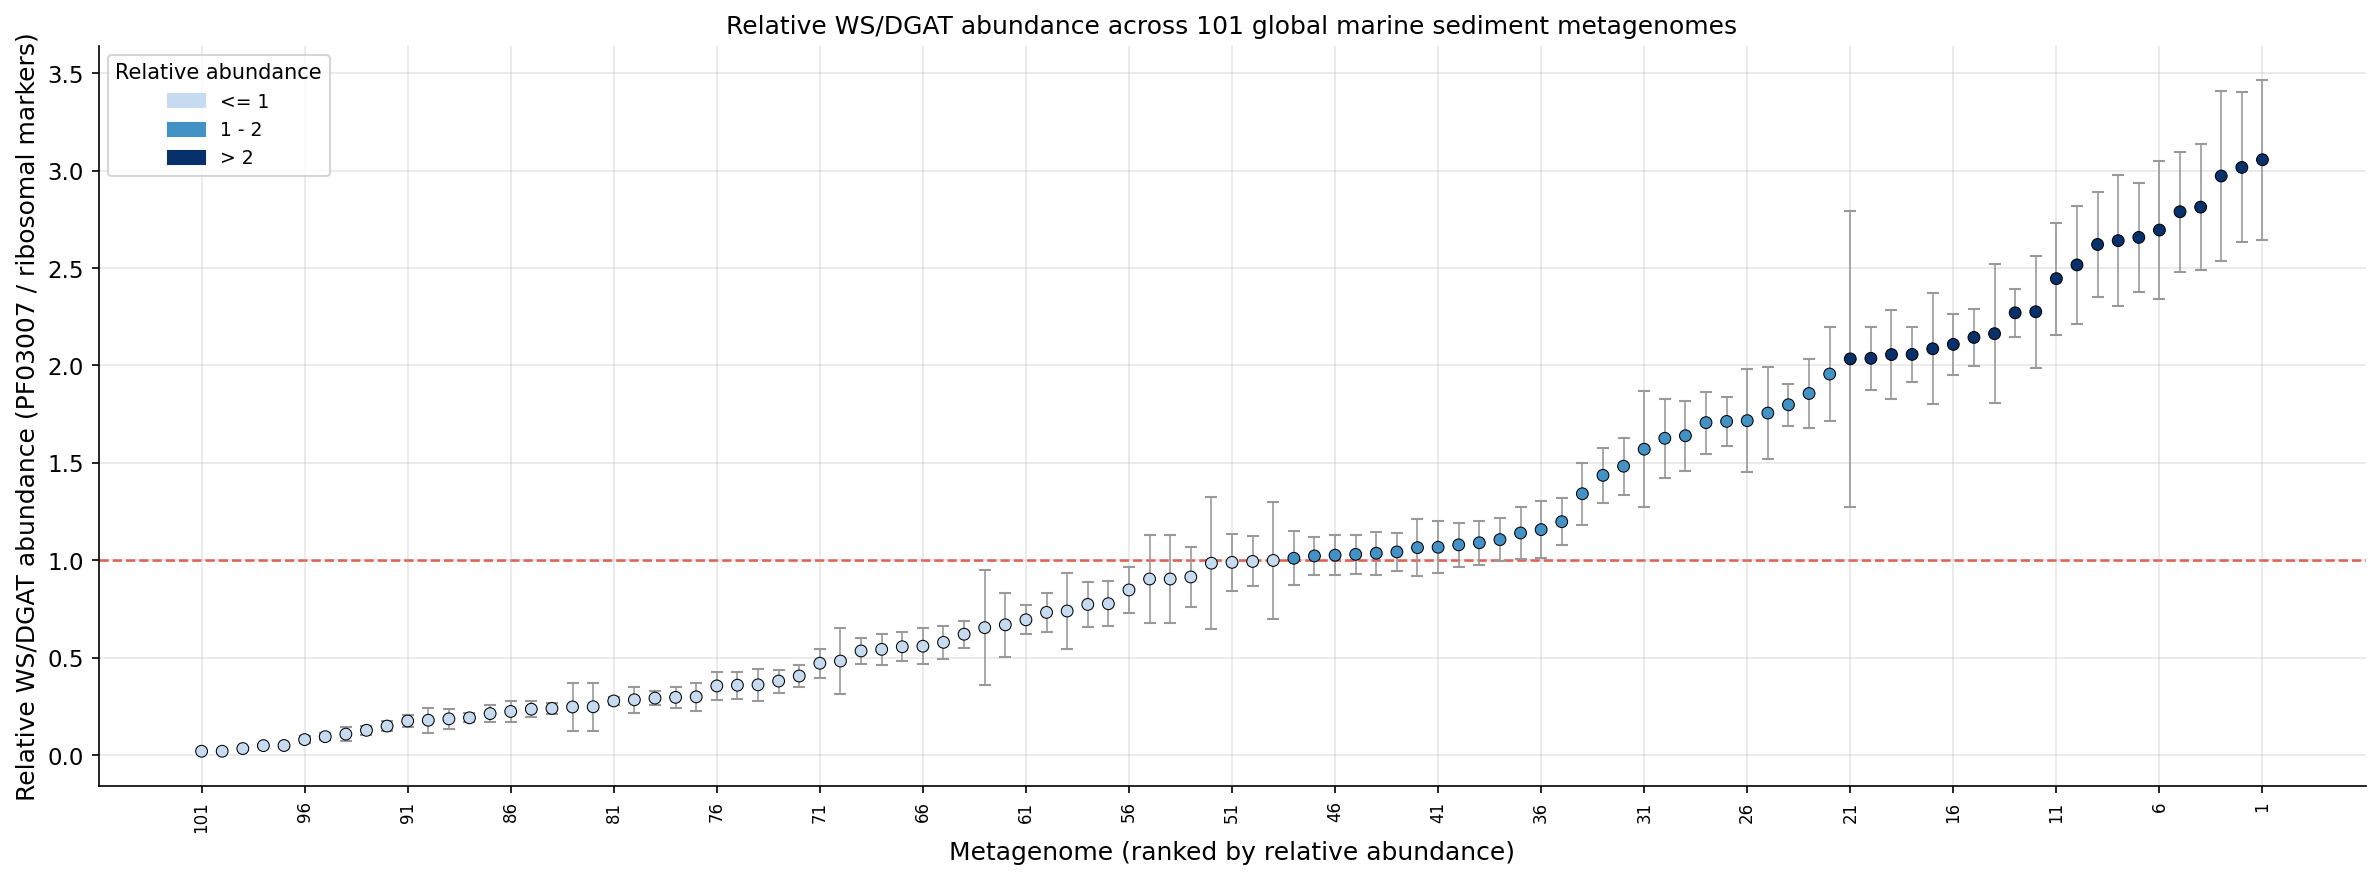

Relative abundance > 1: 48/101 (47.52%)
Relative abundance > 2: 21/101 (20.79%)


In [5]:
df_ranked = df.sort_values('mean_ratio', ascending=True).reset_index(drop=True)
n = len(df_ranked)
x = np.arange(n)

fig, ax = plt.subplots(figsize=(16, 6))

ax.errorbar(
    x, df_ranked['mean_ratio'], yerr=df_ranked['std_ratio'],
    fmt='none', capsize=3, elinewidth=0.8, ecolor='#999999', zorder=2
)
colors = df_ranked['abundance_tier'].map(ABUNDANCE_COLORS)
ax.scatter(x, df_ranked['mean_ratio'], s=32, color=colors, edgecolor='black', linewidth=0.5, zorder=3)

ax.axhline(y=1, color='#E74C3C', linestyle='--', linewidth=1.2, zorder=1)

tick_step = 5
tick_idx = list(range(0, n, tick_step))
if tick_idx[-1] != n - 1:
    tick_idx.append(n - 1)
ax.set_xticks(x[tick_idx])
ax.set_xticklabels(df_ranked['rank'].iloc[tick_idx], rotation=90, fontsize=8)

ax.set_xlabel('Metagenome (ranked by relative abundance)', fontsize=12)
ax.set_ylabel('Relative WS/DGAT abundance (PF03007 / ribosomal markers)', fontsize=12)
ax.set_title(f'Relative WS/DGAT abundance across {n} global marine sediment metagenomes', fontsize=12)

ax.legend(
    handles=[
        mpatches.Patch(color=ABUNDANCE_COLORS['low'], label='<= 1'),
        mpatches.Patch(color=ABUNDANCE_COLORS['medium'], label='1 - 2'),
        mpatches.Patch(color=ABUNDANCE_COLORS['high'], label='> 2')
    ],
    title='Relative abundance', loc='upper left', fontsize=9, title_fontsize=10
)
plt.tight_layout()
plt.savefig('figure1_global_marine_relative_abundance_ranked.png', dpi=300, bbox_inches='tight')
plt.show()

n_over1 = (df['mean_ratio'] > 1).sum()
n_over2 = (df['mean_ratio'] > 2).sum()
print(f'Relative abundance > 1: {n_over1}/{len(df)} ({n_over1/len(df)*100:.2f}%)')
print(f'Relative abundance > 2: {n_over2}/{len(df)} ({n_over2/len(df)*100:.2f}%)')

Nearly half of all globally surveyed marine sediment metagenomes (47.5%) carry more WS/DGAT copies than the average single-copy ribosomal gene, and one in five (20.8%) carry more than double — this is the central result of this notebook. The next section checks whether this is being driven by metagenomes concentrated at a single location, or whether it holds up across genuinely independent, geographically dispersed sites.

## 3. Figure 2 — Global geographic distribution of marine sediment metagenomes

If the elevated relative abundance seen above were driven by a handful of metagenomes from the same location, the result in Section 2 would say little about marine sediments in general. This map plots every metagenome by its reported IMG/M coordinates to check that visually.

Point size is proportional to the number of metagenomes analyzed at that exact location; color indicates the relative-abundance tier (highest tier present, for locations with more than one metagenome).

**Notes on reading this map:**
- **99 of 101 metagenomes have coordinates.** The remaining 2 are "Combined Assembly" IMG/M projects (co-assembled from multiple original samples, e.g. a Caspian Sea combined dataset) that IMG/M does not report a single site for — they are excluded from the map only, not from the abundance statistics above.
- **Nearby circles that look concentric/stacked are real, distinct sampling stations, not a plotting artifact.** IMG/M reports each metagenome's own coordinates, and expeditions frequently sample several stations a few kilometers apart (e.g. along a transect or ridge) — those get their own points, not merged into one. Only metagenomes sharing the *exact same* reported coordinate are collapsed into a single, larger bubble. Zoom or hover on the interactive figure below to separate nearby stations (e.g. the Baltic Sea cluster near Sweden, or the South Atlantic Ridge stations).

In [6]:
df_coords = df.dropna(subset=['latitude', 'longitude']).copy()
print(f'Metagenomes with coordinates: {len(df_coords)} / {len(df)}')
print(f'Metagenomes without coordinates (combined-assembly projects, no single site): {len(df) - len(df_coords)}')

tier_rank = {'low': 0, 'medium': 1, 'high': 2}
df_coords['tier_rank'] = df_coords['abundance_tier'].map(tier_rank)

sites = (
    df_coords.groupby(['latitude', 'longitude'])
    .agg(n_metagenomes=('metagenome_id', 'count'), tier_rank=('tier_rank', 'max'))
    .reset_index()
)
inv_tier = {v: k for k, v in tier_rank.items()}
sites['abundance_tier'] = sites['tier_rank'].map(inv_tier)
sites['Relative abundance'] = sites['abundance_tier'].map(
    {'low': '<= 1', 'medium': '1 - 2', 'high': '> 2'}
)

print(f'Unique exact-coordinate sites: {len(sites)} (multiple sites can still be only a few km apart)')

Metagenomes with coordinates: 99 / 101
Metagenomes without coordinates (combined-assembly projects, no single site): 2
Unique exact-coordinate sites: 39 (multiple sites can still be only a few km apart)


In [7]:
fig_map = px.scatter_geo(
    sites,
    lat='latitude',
    lon='longitude',
    size='n_metagenomes',
    color='Relative abundance',
    category_orders={'Relative abundance': ['<= 1', '1 - 2', '> 2']},
    color_discrete_map={
        '<= 1': ABUNDANCE_COLORS['low'],
        '1 - 2': ABUNDANCE_COLORS['medium'],
        '> 2': ABUNDANCE_COLORS['high']
    },
    projection='natural earth',
    size_max=32,
    title=f'Global distribution of {len(df_coords)} marine sediment metagenomes across {len(sites)} exact-coordinate sites',
    hover_data={'latitude': ':.2f', 'longitude': ':.2f', 'n_metagenomes': True}
)

fig_map.update_traces(marker=dict(line=dict(width=0.8, color='black'), opacity=0.7))
fig_map.update_geos(
    showland=True, landcolor='#f2f2f2',
    showocean=True, oceancolor='#ffffff',
    showcountries=True, countrycolor='#dddddd',
    showcoastlines=True, coastlinecolor='#bbbbbb'
)
fig_map.update_layout(
    legend_title_text='Relative WS/DGAT abundance',
    margin=dict(l=10, r=10, t=50, b=10)
)

fig_map.write_html('figure2_global_marine_metagenomes_map.html', include_plotlyjs='cdn')
try:
    fig_map.write_image('figure2_global_marine_metagenomes_map.png', width=1400, height=700, scale=2)
    print('Static PNG exported.')
except Exception as e:
    print('Static PNG export skipped in this environment (requires Chrome via `plotly_get_chrome`) - see figures/figure2_global_marine_metagenomes_map.png for a static version.')

fig_map

Static PNG export skipped in this environment (requires Chrome via `plotly_get_chrome`) - see figures/figure2_global_marine_metagenomes_map.png for a static version.


![Static preview](../figures/figure2_global_marine_metagenomes_map.png)

> **Note:** the cell above is an interactive Plotly map (hover for per-site details), but GitHub's notebook viewer doesn't render interactive Plotly output, so it may appear blank there — the static preview above covers that case. For the interactive version, open `figures/figure2_global_marine_metagenomes_map.html` directly (or run the notebook locally/in Colab).

**Reading the map:** elevated relative abundance (medium/dark blue) is not confined to one region — it appears in geographically unrelated coastal and estuarine settings (Bohai Sea, China; San Francisco Bay-Delta; Mesquite Bay, Texas), while deep-sea/abyssal sites (Gulf of Mexico abyssal plain, Yap Trench, southwestern Indian Ocean) are consistently low, regardless of geographic region. This pattern — elevated potential near coastal/estuarine, organically-enriched settings and low potential in deep, oligotrophic sediments — supports treating the > 1 / > 2 result from Section 2 as a general property of marine sediment communities tracking local organic input, not an artifact of oversampling one location. The San Francisco Bay-Delta project is explored in more detail next, since it is both the largest single contributor and among the highest in relative abundance.

## 4. Distribution by sequencing project (GOLD Study)

Metagenomes are not independent geographic samples in equal proportion — some IMG/M sequencing projects contributed many metagenomes from the same broader location. Grouping by GOLD Study ID checks whether the overall trend is driven by one heavily-sampled project.

In [8]:
study_summary = (
    df.groupby(['gold_study_id', 'study_name'])
    .agg(
        n_metagenomes=('metagenome_id', 'count'),
        n_over1=('mean_ratio', lambda s: (s > 1).sum()),
        n_over2=('mean_ratio', lambda s: (s > 2).sum()),
        mean_ratio_avg=('mean_ratio', 'mean')
    )
    .sort_values('n_metagenomes', ascending=False)
    .reset_index()
)
study_summary['pct_over1'] = (study_summary['n_over1'] / study_summary['n_metagenomes'] * 100).round(1)
study_summary['mean_ratio_avg'] = study_summary['mean_ratio_avg'].round(3)

print(f'Distinct sequencing projects (GOLD studies): {df["gold_study_id"].nunique()}')
study_summary

Distinct sequencing projects (GOLD studies): 13


,gold_study_id,study_name,n_metagenomes,n_over1,n_over2,mean_ratio_avg,pct_over1
0,Gs0131968,Estuarine microbial communities from the San F...,20,16,9,1.794,80.0
1,Gs0153943,Marine and freshwater sediment microbial commu...,17,9,5,1.431,52.9
2,Gs0150021,Sediment microbial communities from various en...,13,9,0,0.960,69.2
3,Gs0149406,Marine sediment microbial communities from Boh...,12,9,4,1.501,75.0
4,Gs0133492,Microbial communities of deep seafloor calcare...,6,0,0,0.173,0.0
5,Gs0135966,Microbial communities from the deep biosphere,6,1,1,0.603,16.7
6,Gs0142464,Microbial communities from sediments and seawa...,6,0,0,0.815,0.0
7,Gs0133387,Deep seafloor sediment microbial communities f...,5,0,0,0.211,0.0
8,Gs0133265,Abyssal plain sediment microbial communities f...,4,0,0,0.038,0.0
9,Gs0142604,Marine sediment microbial communities from Mes...,4,4,2,1.591,100.0


In [9]:
top_study = study_summary.iloc[0]
print(f"Largest single project: '{top_study['study_name']}'")
print(f"  {int(top_study['n_metagenomes'])}/{len(df)} metagenomes ({int(top_study['n_metagenomes'])/len(df)*100:.1f}% of the dataset)")
print(f"  {int(top_study['n_over1'])} with relative abundance > 1, {int(top_study['n_over2'])} with > 2")

Largest single project: 'Estuarine microbial communities from the San Francisco Bay-Delta (SFBD), California, United States'
  20/101 metagenomes (19.8% of the dataset)
  16 with relative abundance > 1, 9 with > 2


**Interpretation:** the largest single contributor is the *Estuarine microbial communities from the San Francisco Bay-Delta (SFBD), California* project — 20 metagenomes from a genome-resolved metagenomic survey of San Francisco Bay sediments spanning four seasons and five sites (Langwig et al. 2025). This project also shows disproportionately high WS/DGAT relative abundance (16/20 metagenomes > 1; 9/20 > 2).

San Francisco Bay receives large nitrogen and phosphorus loads from agricultural return-flow drains and municipal wastewater treatment discharge, historically the two dominant nutrient sources to the estuary (Hager & Schemel 1992). This anthropogenic nutrient-loading profile parallels Bahía Ushuaia (the MC site in Notebook 01), where the maximum relative WS/DGAT abundance in this entire study was observed and which is similarly impacted by untreated domestic waste discharge. This convergence, in two geographically unrelated but similarly impacted sites, is consistent with — though does not by itself establish — a link between anthropogenic organic/nutrient loading and WS/DGAT biosynthetic potential in marine sediments, worth testing directly in future work with paired environmental metadata.

## 5. Summary table

In [10]:
summary = df[['rank', 'metagenome_id', 'study_name', 'latitude', 'longitude',
              'mean_ratio', 'std_ratio', 'n_valid', 'abundance_tier']].copy()
summary.columns = ['Rank', 'Metagenome ID', 'Study', 'Latitude', 'Longitude',
                    'Rel. abundance (mean)', 'Rel. abundance (SD)', 'N valid ratios', 'Tier']
summary[['Rel. abundance (mean)', 'Rel. abundance (SD)']] = \
    summary[['Rel. abundance (mean)', 'Rel. abundance (SD)']].round(3)

summary.to_csv('global_marine_metagenomes_summary_table.csv', index=False)
print('Exported: global_marine_metagenomes_summary_table.csv')
summary.head(10)

Exported: global_marine_metagenomes_summary_table.csv


,Rank,Metagenome ID,Study,Latitude,Longitude,Rel. abundance (mean),Rel. abundance (SD),N valid ratios,Tier
0,1,3300022306,Estuarine microbial communities from the San F...,37.7000,-122.3400,3.056,0.411,12,high
1,2,3300022308,Estuarine microbial communities from the San F...,37.7000,-122.3400,3.017,0.385,12,high
2,3,3300022206,Estuarine microbial communities from the San F...,37.7000,-122.3400,2.973,0.435,12,high
3,4,3300048070,Marine and freshwater sediment microbial commu...,39.9902,51.5008,2.813,0.323,12,high
4,5,3300022213,Estuarine microbial communities from the San F...,38.0500,-121.9340,2.789,0.309,12,high
5,6,3300048494,Marine and freshwater sediment microbial commu...,39.9902,51.5008,2.695,0.353,12,high
6,7,3300022220,Estuarine microbial communities from the San F...,37.7900,-122.3600,2.657,0.281,12,high
7,8,3300048056,Marine and freshwater sediment microbial commu...,39.9902,51.5008,2.641,0.337,12,high
8,9,3300048057,Marine and freshwater sediment microbial commu...,39.9902,51.5008,2.621,0.272,12,high
9,10,3300022413,Estuarine microbial communities from the San F...,37.7900,-122.3600,2.516,0.305,12,high


- Galván V. et al. (2023). High potential for the biosynthesis of neutral lipid storage compounds in chronically-polluted subantarctic sediments. *PLOS ONE*, 18(7). https://doi.org/10.1371/journal.pone.0288509
- Hager SW, Schemel LE (1992). Sources of Nitrogen and Phosphorus to Northern San Francisco Bay. *Estuaries*, 15(1), 40-52. https://doi.org/10.2307/1352708
- Langwig MV, Sneed SL, Rasmussen A, Seitz KW, Lee JA, Anantharaman K, De Anda V, Francis CA, Baker BJ (2025). Metabolic capacity is maintained despite shifts in microbial diversity in estuary sediments. *ISME Communications*, 5(1), ycaf182. https://doi.org/10.1093/ismeco/ycaf182
- Pfam domain PF03007: https://www.ebi.ac.uk/interpro/entry/pfam/PF03007/
- Chen IA, Chu K, Palaniappan K, et al. (2021). The IMG/M data management and analysis system v.6.0: new tools and advanced capabilities. *Nucleic Acids Research*, 49(D1), D751–D763. https://doi.org/10.1093/nar/gkaa939